<a href="https://colab.research.google.com/github/Sarthaak-19/Heart-Disease_prediction_data_science_project/blob/main/Heart_diseases_predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# importing library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# load dataset

df = pd.read_csv(
    "https://raw.githubusercontent.com/g-shreekant/Heart-Disease-Prediction-using-Machine-Learning/master/heart.csv"
)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# 3 EDA
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.shape

(303, 14)

In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df.isnull().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [8]:
# features seprate preprocessing steps
x=df.drop('target',axis=1)
y=df['target']

In [9]:
# standard scaler and train test split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [10]:
sc=StandardScaler()
#train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

Logistic regression

In [11]:
#training model
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)
lr_y_pred=lr.predict(x_test)

SVM

In [14]:
from sklearn.svm import SVC
svm=SVC(random_state=42)
svm.fit(x_train,y_train)
y_svm_pred=svm.predict(x_test)

KNN

In [15]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)
y_knn_pred=model.predict(x_test)

XGBOOST

In [17]:
from xgboost import XGBClassifier
xgb=XGBClassifier(random_state=42)
xgb.fit(x_train,y_train)
y_xgb_pred=xgb.predict(x_test)

In [18]:
# model evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Logistic regression (accuracy):-",accuracy_score(y_test,lr_y_pred))
print("classification_report:-",classification_report(y_test,lr_y_pred))

print("\n Svm(accuracy):-",accuracy_score(y_test,y_svm_pred))
print("classification report:-",classification_report(y_test,y_svm_pred))

print("\n KNN(accuracy):-",accuracy_score(y_test,y_knn_pred))
print("classification report:-",classification_report(y_test,y_knn_pred))

print("\n XGBOOST(accuracy):-",accuracy_score(y_test,y_xgb_pred))
print("classification report:-",classification_report(y_test,y_xgb_pred))


Logistic regression (accuracy):- 0.8524590163934426
classification_report:-               precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61


 Svm(accuracy):- 0.8688524590163934
classification report:-               precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61


 KNN(accuracy):- 0.9016393442622951
classification report:-               precision    recall  f1-score   support

           0       0.87      0.93      0.90        29
           1       0.93      0.88      

In [19]:
# graph confusion matrix
cm_svm=confusion_matrix(y_test,y_svm_pred)
cm_knn=confusion_matrix(y_test,y_knn_pred)
cm_lr=confusion_matrix(y_test,lr_y_pred)

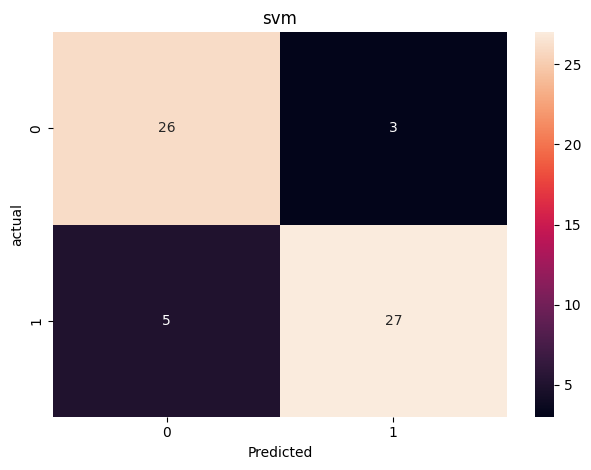

In [20]:
# graph
sns.heatmap(cm_svm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('actual')
plt.title('svm')
plt.tight_layout()

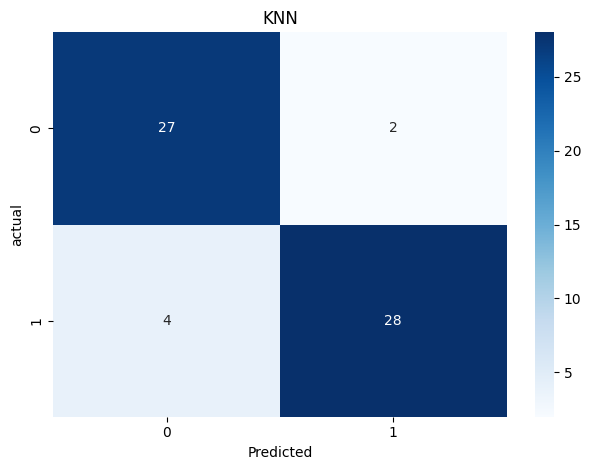

In [25]:
sns.heatmap(cm_knn,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('actual')
plt.title('KNN')
plt.tight_layout()

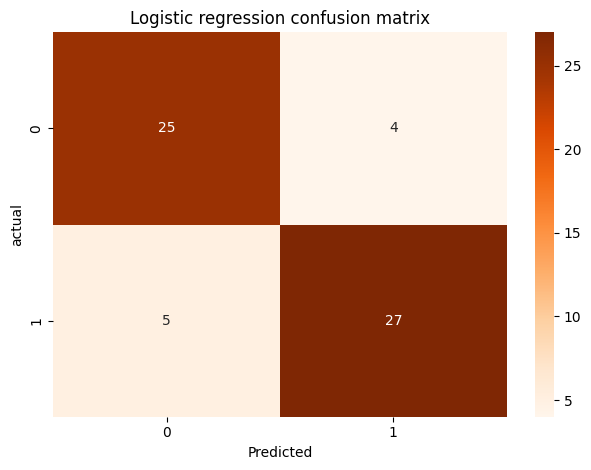

In [26]:
sns.heatmap(cm_lr,annot=True,fmt='d',cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('actual')
plt.title('Logistic regression confusion matrix')
plt.tight_layout()